# Cox-BNN
## A Bayesian Neural Network for Sruvival Analysis

**Authors**: Alice Conighi, Emanuele Valea, Giovanni Zedda

<small>Final project for Probabilistic and Machine Learning course held by Prof. Luca Bortolussi at University of Trieste A.Y. 2025/2026.</small>


In [1]:
from ucimlrepo import list_available_datasets, fetch_ucirepo
list_available_datasets(search='AIDS')

-------------------------------------------------------------
The following datasets are available for search query "aids":
-------------------------------------------------------------
Dataset Name                            ID    
------------                            --    
AIDS Clinical Trials Group Study 175    890   



In [2]:
aids_clinical_trials_group = fetch_ucirepo(id=890) 
print(aids_clinical_trials_group.keys())

dict_keys(['data', 'metadata', 'variables'])


In [3]:
print(aids_clinical_trials_group.data['features'].keys())
print(aids_clinical_trials_group.data['targets'].keys())

Index(['time', 'trt', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof',
       'oprior', 'z30', 'zprior', 'preanti', 'race', 'gender', 'str2', 'strat',
       'symptom', 'treat', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820'],
      dtype='str')
Index(['cid'], dtype='str')


### Exploratory Data Analysis and Preprocessing

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
aids: pd.DataFrame = pd.concat([
        aids_clinical_trials_group.data['features'], 
        aids_clinical_trials_group.data['targets']
    ], axis=1
)

In [15]:
pd.options.display.max_columns = None
display(aids.head())

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,zprior,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
0,948,2,48,89.8128,0,0,0,100,0,0,1,0,0,0,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,1,895,0,0,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,1,1352,0,1,1,3,0,0,0,504,353,870,782,0


In [8]:
print('Total number of observations:', len(aids))
print(f"Total number of censored data: {aids.cid.sum()} ({100*aids.cid.mean():.2f}%)")

Total number of observations: 2139
Total number of censored data: 521 (24.36%)


In [141]:
aids.std()[aids.std()<0.2]

oprior    0.146629
zprior    0.000000
dtype: float64

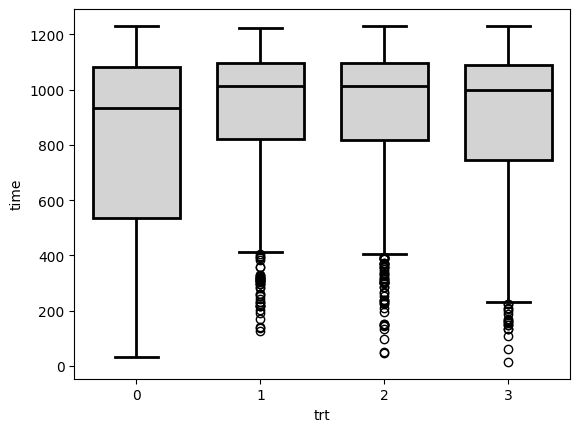

In [17]:
# fig, axes = plt.subplots(1, 2)
sns.boxplot(data=aids, x='trt', y='time', color='lightgrey', 
            linecolor='black', linewidth=2, width=0.7)#, ax=axes[0])
# sns.boxplot(data=aids, x='homo', y='time', color='lightgrey', 
#             linecolor='black', linewidth=2, width=0.7, ax=axes[1])
plt.show()

In [22]:
aids.groupby('strat')[['preanti']].mean()
# strat:
    # antiretroviral history stratification (1='Antiretroviral Naive',
    #                                        2='> 1 but <= 52 weeks of prior antiretroviral therapy',
    #                                        3='> 52 weeks)
# preanti:
    # days pre-175 anti-retroviral therapy

,preanti
strat,
1,0.081264
2,186.890244
3,871.126928


In [29]:
from collections import OrderedDict
from itertools import pairwise
from typing import Any, Callable, Sequence

import torch
import torch.nn as nn
import torch.nn.functional as F

In [25]:
# https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/DL2/Bayesian_Neural_Networks/dl2_bnn_tut1_students_with_answers.html

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample

In [ ]:
class BayesianLinear(PyroModule):
    def __init__(self, in_dim: int, out_dim: int, prior_sigma: float = 3.0):
        super().__init__()
        self.layer = PyroModule[nn.Linear](in_dim, out_dim)


In [ ]:
class BayesianGaussianLinear(nn.Module):
    """
    Parameters: mu_w, rho_w (weights), mu_b, rho_b (biases).
    sigma = softplus(rho) ensures positivity without constraints.
    """
    def __init__(self, in_dim: int, out_dim: int, prior_sigma: float = 2.0):
        super().__init__()
        self.in_dim  = in_dim
        self.out_dim = out_dim
        self.prior_sigma  = prior_sigma

        kaiming_he_sigma = 4/(in_dim+out_dim)

        # Variational parameters for weights: shape (out, in)
        self.mu_w = nn.Parameter(torch.empty(out_dim, in_dim).normal_(0, kaiming_he_sigma))
        self.rho_w = nn.Parameter(torch.empty(out_dim, in_dim).fill_(-2.5))

        # Variational parameters for biases: shape (out,)
        self.mu_b = nn.Parameter(torch.empty(out_dim).normal_(0, 0.1))
        self.rho_b = nn.Parameter(torch.empty(out_dim).fill_(-2.5))


    def _sigma(self, rho: nn.Parameter):
        """Softplus riparametrization."""
        sigma = F.softplus(rho) + 1e-8
        return sigma


    def _kl_gaussian(self, mu: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        """KL Divergence (closed formula) between prior and 
        variational posterior with mean field assumption.
        """
        sigma0 = self.prior_sigma
        kl = (torch.log(sigma0/sigma) + (sigma**2 + mu**2) / (2*sigma0**2) - 1/2).sum()
        return kl
    

    def layer_kl(self) -> torch.Tensor:
        # Softplus transformation
        sigma_w = self._sigma(self.rho_w) # (out, in)
        sigma_b = self._sigma(self.rho_b) # (out,)
        return(
            self._kl_gaussian(self.mu_w, sigma_w) 
            + self._kl_gaussian(self.mu_b, sigma_b)
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x has size (B, nodes)

        # Softplus transformation
        sigma_w = self._sigma(self.rho_w) # (out, in)
        sigma_b = self._sigma(self.rho_b) # (out,)
        # Reparametrization
        eps_w = torch.randn_like(self.mu_w)
        eps_b = torch.randn_like(self.mu_b)
        W = sigma_w*eps_w + self.mu_w
        b  = sigma_b*eps_b + self.mu_b

        # Standard linear transformation
        out = x @ W.T + b

        # KL contribution from this layer
        # kl = self._kl_gaussian(self.mu_w, sigma_w) + self._kl_gaussian(self.mu_b, sigma_b)

        return out

In [102]:
class BayesianMLP(nn.Module):
    def __init__(self, *size: int, prior_sigma: float = 1.0):
        if len(size) < 1:
            raise ValueError('At least one size (input size) must be provided')
        super().__init__()
        self.size = size
        self.prior_sigma = prior_sigma
        self.net = self.__make_net()


    def __make_net(self) -> nn.Sequential:
        layers: list[tuple[str, nn.Module]] = []
        for k, (s_in, s_out) in enumerate(pairwise(self.size)):
            layers.append((f"l{k}", BayesianGaussianLinear(s_in, s_out, self.prior_sigma)))
            layers.append((f"h{k}", nn.Tanh()))
        layers.append(('out', BayesianGaussianLinear(self.size[-1], 1, self.prior_sigma)))
        return nn.Sequential(OrderedDict(layers))

    def network_kl(self) -> torch.Tensor:
        kl = torch.tensor(0.0, dtype=torch.float)
        for layer in self.net:
            if hasattr(layer, 'layer_kl'):
                kl += layer.layer_kl()
        return kl

    def forward(self, x):
        return self.net(x)

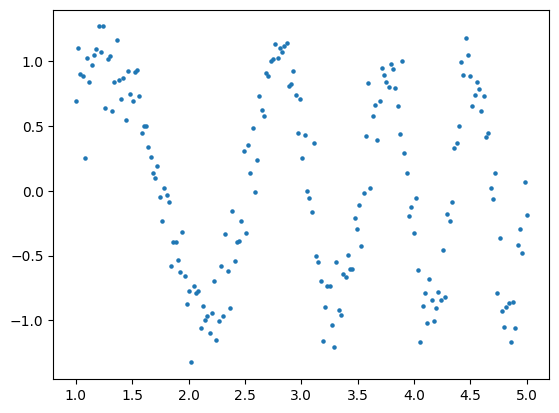

In [95]:
x = torch.linspace(1.0, 5.0, 200)
y = torch.sin(x**2) + 0.2*torch.randn_like(x)
plt.scatter(x, y, s=5)

In [ ]:
model = BayesianMLP(1, 5, 5, 1, prior_sigma=3.0)

def elbo_loss_naive(y_pred, y_true, kl, N, sigma_obs=0.2):
    """
    Negative ELBO = Sum of NLL over dataset + Total KL
    """
    # Calcoliamo la NLL per ogni campione
    # p(y|x,w) = Gaussian
    nll_per_sample = 0.5 * torch.log(torch.tensor(2 * torch.pi * sigma_obs**2)) + (1 / (2 * sigma_obs**2)) * (y_true - y_pred)**2
    
    # Sommiamo su tutto il dataset (N)
    total_nll = nll_per_sample.sum()
    
    # L'obiettivo da minimizzare è NLL_totale + KL_totale
    return total_nll + kl

In [242]:
optimiser = torch.optim.Adam(model.parameters(), lr=1e-2)

plt.suptitle('Variational Posterior: $(\\mu_j, \\sigma_j)$ per weight', fontsize=12)
plt.tight_layout(); plt.show()

N = len(x)
n_epochs = 3000
losses = []

for epoch in range(n_epochs):
    model.train()
    optimiser.zero_grad()
    # print(x.size())
    # x = x.view(-1, 1)
    # print(x.shape)
    y_pred = model(x.view(-1, 1))
    kl = model.network_kl()

    loss = elbo_loss_naive(y_pred, y, kl, N, sigma_obs=0.5)
    loss.backward()
    optimiser.step()

    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses, lw=0.8)
# plt.ylim(52000, 52500)
plt.xlabel('Epoch'); plt.ylabel(r'$-\mathcal{L}$')
plt.title('Negative ELBO during training')
plt.tight_layout(); plt.show()
print(f'Final loss: {losses[-1]:.2f}')

<Figure size 640x480 with 0 Axes>

NameError: name 'elbo_loss_naive' is not defined

[0.06684867 0.06697988 0.0671108  0.06724137 0.06737156 0.06750131
 0.06763057 0.0677593  0.06788743 0.06801493 0.06814174 0.06826782
 0.06839313 0.06851762 0.06864124 0.06876396 0.06888572 0.0690065
 0.06912624 0.06924492]


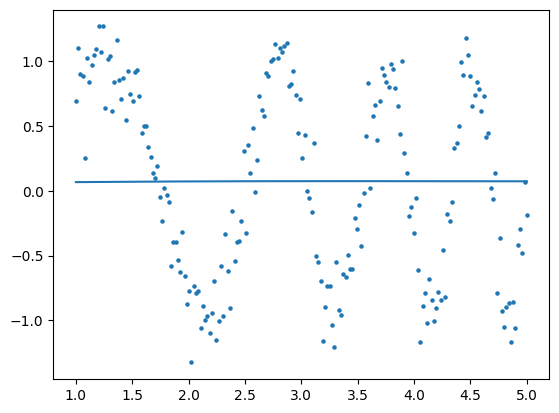

In [118]:
model.eval()
yhat = model(x.view(-1, 1)).squeeze().detach().numpy()
print(yhat[:20])
plt.scatter(x, y, s=5)
plt.plot(x, yhat)

In [219]:
def cox_partial_loglik(t: torch.Tensor, 
                       delta: torch.Tensor, 
                       loghr_hat: torch.Tensor) -> torch.Tensor:
    """Cox Partial Likelihood (the negative is a loss component)

    Parameters
    ----------
    t : Tensor[float]
        Time to event or censoring
    delta : Tensor[float]
        Indicator `1.0` is observed
    loghr_hat : Tensor[float]
        Output of the BNN
    
    All inputs must be reduced to size (BATCH_SIZE,).
    
    Returns
    -------
    ll : ScalarTensor
        The partial log-likelihood for a Cox proportional hazards model
        with Breslow tie-breaker.

        Sum_{i: delta_i==1} [h - log Sum_{j: t_j>=t_i} exp(h)]

        h output of the neural network.
    """
    assert len(t.shape) == len(delta.shape) == len(loghr_hat.shape) == 1, "All inputs must be reduced to size (BATCH_SIZE,)"
    hr_hat = torch.exp(loghr_hat)
    riskset = t.view(-1, 1) <= t.repeat(len(t), 1) 
        # boolean matrix where the `i`-th row denotes the
        # risk set of the `i`-th instance, i.e. the indices `j`
        # for which the observer time `y_j >= y_i`.

    # ll = loghr_hat.where(delta>0, 0.0).sum()
    # for t_i in t[delta>0]:
    #     ll -= torch.log(
    #         hr_hat.where(t>=t_i, 0.0).sum()
    #     )

    log_denominator = torch.log(
        (riskset*hr_hat.repeat(len(hr_hat), 1)).sum(dim=1)
    )
    ll = ((delta > 0) * (loghr_hat - log_denominator)).sum()

    return ll


def cox_elbo_loss(t: torch.Tensor,
              delta: torch.Tensor,
              loghr_hat: torch.Tensor,
              kl: torch.Tensor):
    """Negative partial lok-likelihood + KL(q(theta) || p(theta))"""
    assert t.shape == delta.shape == loghr_hat.shape, "Tensor sizes must match."
    batch_size = len(t)
    # kl_weight = batch_size / N
    nll = -cox_partial_loglik(t, delta, loghr_hat)
    return nll + kl


In [ ]:
prova = torch.tensor([12.0, 25.0, 33.0, 56.0, 6.0, 80.0])
print(prova.repeat(len(prova), 1))
mask = prova.view(-1, 1) <= prova.repeat(len(prova), 1)
print(mask)

tensor([[12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.],
        [12., 25., 33., 56.,  6., 80.]])
tensor([[ True,  True,  True,  True, False,  True],
        [False,  True,  True,  True, False,  True],
        [False, False,  True,  True, False,  True],
        [False, False, False,  True, False,  True],
        [ True,  True,  True,  True,  True,  True],
        [False, False, False, False, False,  True]])


In [187]:
torch.tensor([True, False, True, False, True, False]) * prova

tensor([12.,  0., 33.,  0.,  6.,  0.])

In [161]:
vec = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
print(vec.repeat(len(vec), 1))
(mask*vec.repeat(len(vec), 1)).sum(dim=1)

tensor([[1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.],
        [1., 2., 3., 4., 5., 6.]])


tensor([16., 15., 13., 10., 21.,  6.])

In [185]:
prova2 = torch.tensor([[1.5, 2.5], [0, 0], [2., 30.0]])
print(prova2)
print(prova2[0])
prova2.sum(dim=1)
prova2.view(-1)
print(prova2.std(dim=0))
print(prova2.mean(dim=0, keepdim=False))
print(prova2.mean(dim=0, keepdim=True))
print(prova2 - prova2.mean(dim=0, keepdim=False))
print(prova2 - prova2.mean(dim=0, keepdim=True))
(prova2 - prova2.mean(dim=0, keepdim=True)) / prova2.std(dim=0)

tensor([[ 1.5000,  2.5000],
        [ 0.0000,  0.0000],
        [ 2.0000, 30.0000]])
tensor([1.5000, 2.5000])
tensor([ 1.0408, 16.6458])
tensor([ 1.1667, 10.8333])
tensor([[ 1.1667, 10.8333]])
tensor([[  0.3333,  -8.3333],
        [ -1.1667, -10.8333],
        [  0.8333,  19.1667]])
tensor([[  0.3333,  -8.3333],
        [ -1.1667, -10.8333],
        [  0.8333,  19.1667]])


tensor([[ 0.3203, -0.5006],
        [-1.1209, -0.6508],
        [ 0.8006,  1.1514]])

In [193]:
import numpy as np

from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

In [195]:
aids

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,zprior,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,cid
0,948,2,48,89.8128,0,0,0,100,0,0,1,0,0,0,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,1,895,0,0,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,1,1352,0,1,1,3,0,0,0,504,353,870,782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,1091,3,21,53.2980,1,0,0,100,0,1,1,842,0,1,1,3,0,1,1,152,109,561,720,0
2135,395,0,17,102.9672,1,0,0,100,0,1,1,417,1,1,1,3,0,0,1,373,218,1759,1030,0
2136,1104,2,53,69.8544,1,1,0,90,0,1,1,753,1,1,1,3,0,1,0,419,364,1391,1041,0
2137,465,0,14,60.0000,1,0,0,100,0,0,1,0,0,1,0,1,0,0,0,166,169,999,1838,1


In [199]:
pd.get_dummies(
    aids.drop(columns=['time', 'zprior', 'cid']),
    columns=['trt'],
    dtype=np.float64
)

,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,preanti,race,gender,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,trt_0,trt_1,trt_2,trt_3
0,48,89.8128,0,0,0,100,0,0,0,0,0,0,1,0,1,0,422,477,566,324,0.0,0.0,1.0,0.0
1,61,49.4424,0,0,0,90,0,1,895,0,0,1,3,0,1,0,162,218,392,564,0.0,0.0,0.0,1.0
2,45,88.4520,0,1,1,90,0,1,707,0,1,1,3,0,1,1,326,274,2063,1893,0.0,0.0,0.0,1.0
3,47,85.2768,0,1,0,100,0,1,1399,0,1,1,3,0,1,0,287,394,1590,966,0.0,0.0,0.0,1.0
4,43,66.6792,0,1,0,100,0,1,1352,0,1,1,3,0,0,0,504,353,870,782,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2134,21,53.2980,1,0,0,100,0,1,842,0,1,1,3,0,1,1,152,109,561,720,0.0,0.0,0.0,1.0
2135,17,102.9672,1,0,0,100,0,1,417,1,1,1,3,0,0,1,373,218,1759,1030,1.0,0.0,0.0,0.0
2136,53,69.8544,1,1,0,90,0,1,753,1,1,1,3,0,1,0,419,364,1391,1041,0.0,0.0,1.0,0.0
2137,14,60.0000,1,0,0,100,0,0,0,0,1,0,1,0,0,0,166,169,999,1838,1.0,0.0,0.0,0.0


In [203]:
from helpers import StandardScaler
scaler = StandardScaler()
design_matrix = torch.tensor(
    pd.get_dummies(
        aids.drop(columns=['time', 'zprior', 'cid']),
        columns=['trt'],
        dtype=np.float64
    ).values,
    dtype = torch.float
)

design_matrix = scaler.fit_transform(design_matrix)
design_matrix


tensor([[ 1.4642,  1.1074, -0.3031,  ..., -0.5680,  1.7552, -0.5961],
        [ 2.9569, -1.9364, -0.3031,  ..., -0.5680, -0.5695,  1.6768],
        [ 1.1197,  1.0048, -0.3031,  ..., -0.5680, -0.5695,  1.6768],
        ...,
        [ 2.0383, -0.3974,  3.2982,  ..., -0.5680,  1.7552, -0.5961],
        [-2.4398, -1.1404,  3.2982,  ..., -0.5680, -0.5695, -0.5961],
        [ 1.1197,  0.1640,  3.2982,  ..., -0.5680, -0.5695,  1.6768]])

In [209]:
time = torch.tensor(aids.time, dtype=torch.float)
delta = torch.tensor(aids.cid)

dataset = TensorDataset(design_matrix, time, delta)
generator = torch.Generator()
generator.manual_seed(42) # other seeds are possible
loader = DataLoader(dataset, batch_size=128, generator=generator)

In [ ]:
def train(model: BayesianMLP, loader: DataLoader, 
          optimizer: optim.Optimizer, n_epochs: int = 100) -> np.ndarray:
    losses = -10 * np.ones(n_epochs, dtype=np.float32) 
        # negative initialization to avoid 
        # ambiguities in case of early stopping
    N: int = len(loader.dataset)
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0
        total_kl = 0
        for i, (x, t, delta) in enumerate(loader):
            B = len(x)
            optimizer.zero_grad()
            loghr_hat = model(x)
            model_kl = model.network_kl() 
            scaled_kl = B/N * model_kl
            loss = cox_elbo_loss(t, delta, loghr_hat.view(-1), scaled_kl)
            loss.backward()
            optimizer.step()
            total_kl += scaled_kl.item()
            total_loss += loss.item()
            print(f"Epoch {epoch: 5d}, Batch {i: 3d}, Loss {loss.item():.3f}" 
                  f" (of which {scaled_kl.item():.3f} KL)", end='\r')
        avg_loss = total_loss / len(loader)
        avg_kl = total_kl / len(loader)
        losses[epoch] = avg_loss
        print(f"Epoch {epoch: 5d}, Average loss {avg_loss:.3f} (of which {avg_kl:.3f} KL)", end= '\n' if epoch % 250 == 0 else '\r')
    return losses


In [228]:
bnn = BayesianMLP(24, 72, 72, 1, prior_sigma=3.0)
optimizer = optim.Adam(bnn.parameters(), lr=0.001)
losses = train(bnn, loader, optimizer, n_epochs=1000)

Epoch     0, Average loss 1453.797 (of which 1313.477 KL)L))
Epoch   250, Average loss 435.709 (of which 302.050 KL)KL)))
Epoch   500, Average loss 245.304 (of which 109.953 KL)L))
Epoch   750, Average loss 199.649 (of which 64.108 KL)KL))


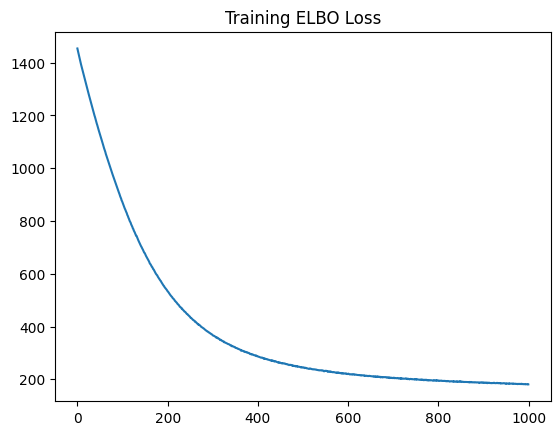

In [236]:
plt.plot(losses)
plt.title("Training ELBO Loss")
plt.show()

In [239]:
bnn.eval()
S = 100
samples = torch.zeros(len(dataset), 100)
for j in range(S):
    samples[:,j] = bnn(design_matrix).view(-1)

In [241]:
samples.mean(dim=1)

tensor([-0.6444,  0.1578,  0.2289,  ..., -0.3880,  0.2341, -0.6989],
       grad_fn=<MeanBackward1>)